In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(color_codes=True, style='darkgrid')

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
df = pd.read_csv('/content/drive/MyDrive/Data mining Lab/Projrct/dhaka_air_quality_2000_2025.csv')
df.head()

,datetime,AQI,PM2.5,PM10,O3,NO2,SO2,CO,Temperature,Humidity,Wind_Speed,Pressure
0,2000-01-01 00:00:00,121.861086,44.200712,93.224101,20.586862,15.391414,28.219932,1.049477,20.956667,71.272569,8.375675,1011.742574
1,2000-01-01 01:00:00,99.598077,35.212704,78.893066,22.429471,26.824534,24.385188,0.943859,13.761031,42.616871,10.880553,1010.949986
2,2000-01-01 02:00:00,132.852834,48.575428,118.693959,37.838094,33.403493,28.951413,0.887131,20.216907,59.169387,15.041183,1012.065387
3,2000-01-01 03:00:00,154.588259,64.208516,86.427166,26.747684,12.137395,26.950990,0.793261,18.642574,62.756439,9.904413,1010.162227
4,2000-01-01 04:00:00,114.102260,41.112699,70.193382,33.192759,25.313206,20.741976,1.059887,18.834718,56.369280,14.632070,1007.067421


In [17]:
df.shape

(225816, 12)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225816 entries, 0 to 225815
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   datetime     225816 non-null  object 
 1   AQI          225816 non-null  float64
 2   PM2.5        225816 non-null  float64
 3   PM10         225816 non-null  float64
 4   O3           225816 non-null  float64
 5   NO2          225816 non-null  float64
 6   SO2          225816 non-null  float64
 7   CO           225816 non-null  float64
 8   Temperature  225816 non-null  float64
 9   Humidity     225816 non-null  float64
 10  Wind_Speed   225816 non-null  float64
 11  Pressure     225816 non-null  float64
dtypes: float64(11), object(1)
memory usage: 20.7+ MB


In [19]:
df.describe()

,AQI,PM2.5,PM10,O3,NO2,SO2,CO,Temperature,Humidity,Wind_Speed,Pressure
count,225816.000000,225816.000000,225816.000000,225816.000000,225816.000000,225816.000000,225816.000000,225816.000000,225816.000000,225816.000000,225816.000000
mean,173.879455,105.495390,178.668865,50.070796,34.295663,23.082057,1.644556,26.042161,70.020460,12.998380,1012.958425
std,47.853187,55.878730,95.030366,18.186844,12.189406,7.695508,0.535873,5.142185,10.623508,4.937334,7.866261
min,20.833333,5.000000,10.000000,5.000000,5.000000,2.000000,0.100000,10.345658,30.000000,8.000005,990.000000
25%,153.495856,62.135134,105.427706,37.130329,25.622285,17.721737,1.256414,22.084894,62.332422,9.447585,1007.622862
50%,171.495329,96.298134,164.382639,48.391279,33.784039,22.485259,1.612679,26.067808,69.341643,11.473965,1012.991058
75%,194.740957,140.418337,240.081570,61.145886,42.605845,27.792577,2.012451,29.997338,77.493987,14.940992,1018.406142
max,299.599600,250.000000,400.000000,124.493286,87.302685,57.272041,3.764566,40.000000,95.000000,40.000000,1030.000000


In [20]:
df.describe(include='O')

,datetime
count,225816
unique,225816
top,2025-10-04 23:00:00
freq,1


# **EDA**

In [21]:
df.columns

Index(['datetime', 'AQI', 'PM2.5', 'PM10', 'O3', 'NO2', 'SO2', 'CO',
       'Temperature', 'Humidity', 'Wind_Speed', 'Pressure'],
      dtype='object')

In [22]:
df.nunique()

,0
datetime,225816
AQI,220121
PM2.5,220121
PM10,217566
O3,225620
NO2,224926
SO2,225696
CO,225764
Temperature,225775
Humidity,223417


In [23]:
# datetime handle
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

df['Year'] = df['datetime'].dt.year
df['Month'] = df['datetime'].dt.month
df['Hour'] = df['datetime'].dt.hour

In [24]:
# Drop datetime (model-এ ব্যবহার করবো না)
df.drop(columns='datetime', inplace=True)

In [13]:
# Pairplot (target = AQI)
sns.pairplot(data=df[['AQI','PM2.5','PM10','O3','NO2','SO2','CO','Temperature','Humidity','Wind_Speed']], diag_kind='kde')

Output hidden; open in https://colab.research.google.com to view.

In [25]:
# AQI Distribution
fig = px.histogram(df, x='AQI', nbins=40, title='Distribution of AQI')
fig.show()

Output hidden; open in https://colab.research.google.com to view.

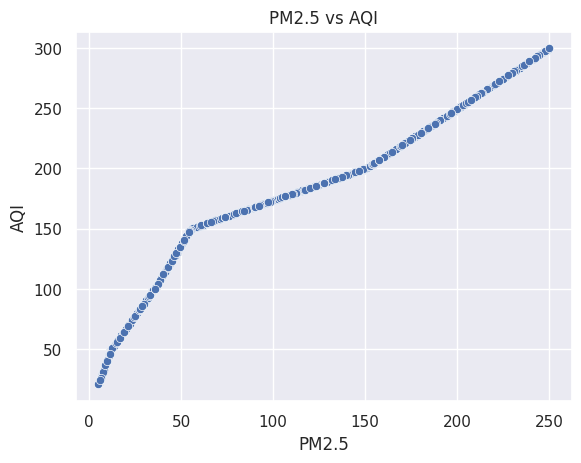

In [26]:
# PM2.5 vs AQI
sns.scatterplot(x='PM2.5', y='AQI', data=df)
plt.title('PM2.5 vs AQI')
plt.show()

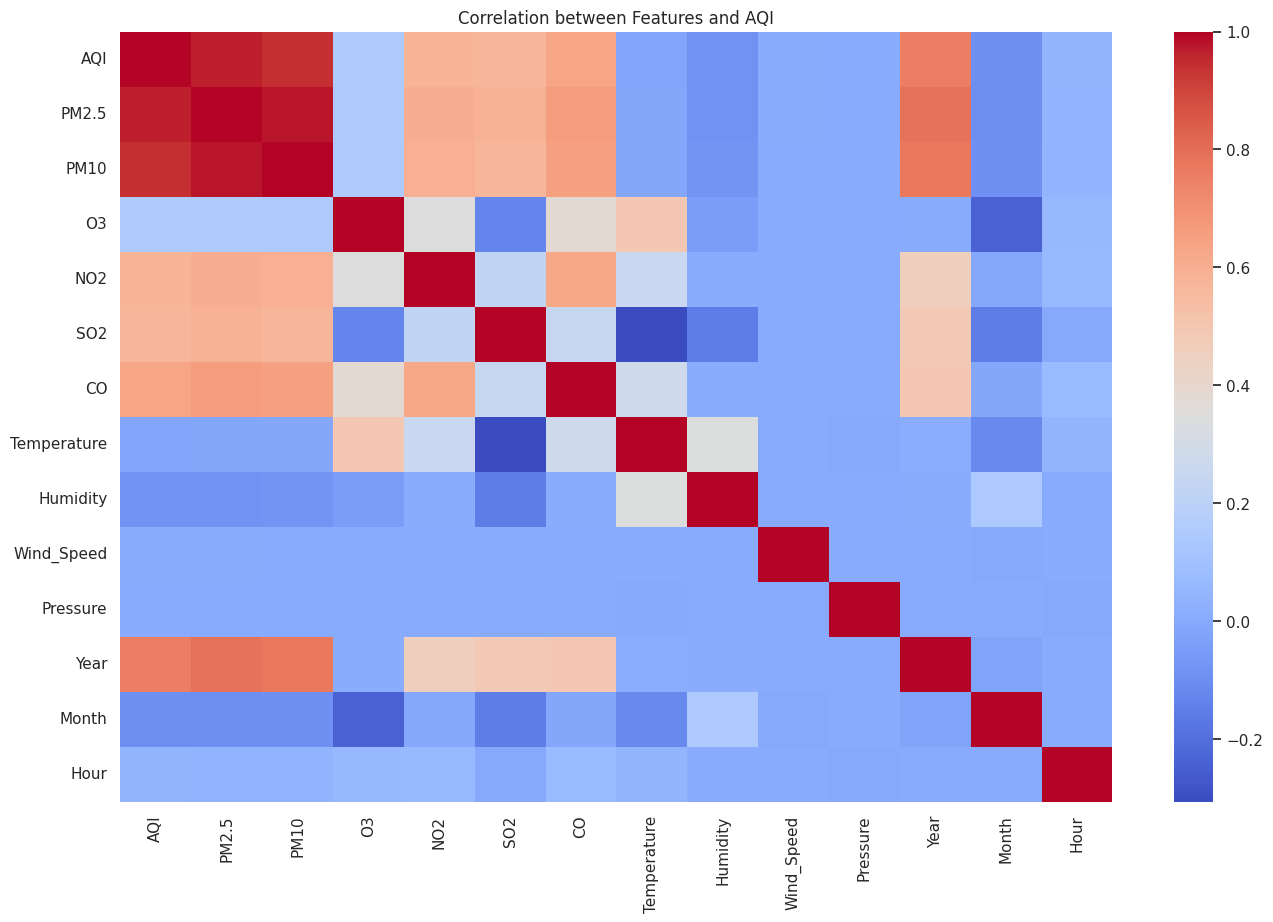

In [27]:
# Correlation Heatmap
corr = df.corr(numeric_only=True)

plt.figure(figsize=(16,10))
sns.heatmap(corr, fmt='.2f', annot=False, cmap='coolwarm')
plt.title('Correlation between Features and AQI')
plt.show()

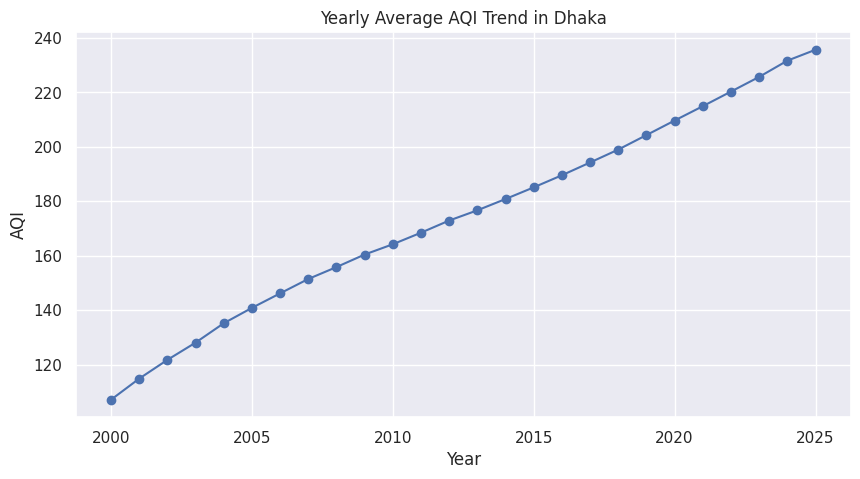

In [28]:
# Yearly AQI trend
yearly_avg = df.groupby('Year')['AQI'].mean()

plt.figure(figsize=(10,5))
yearly_avg.plot(kind='line', marker='o')
plt.title("Yearly Average AQI Trend in Dhaka")
plt.xlabel("Year")
plt.ylabel("AQI")
plt.grid(True)
plt.show()

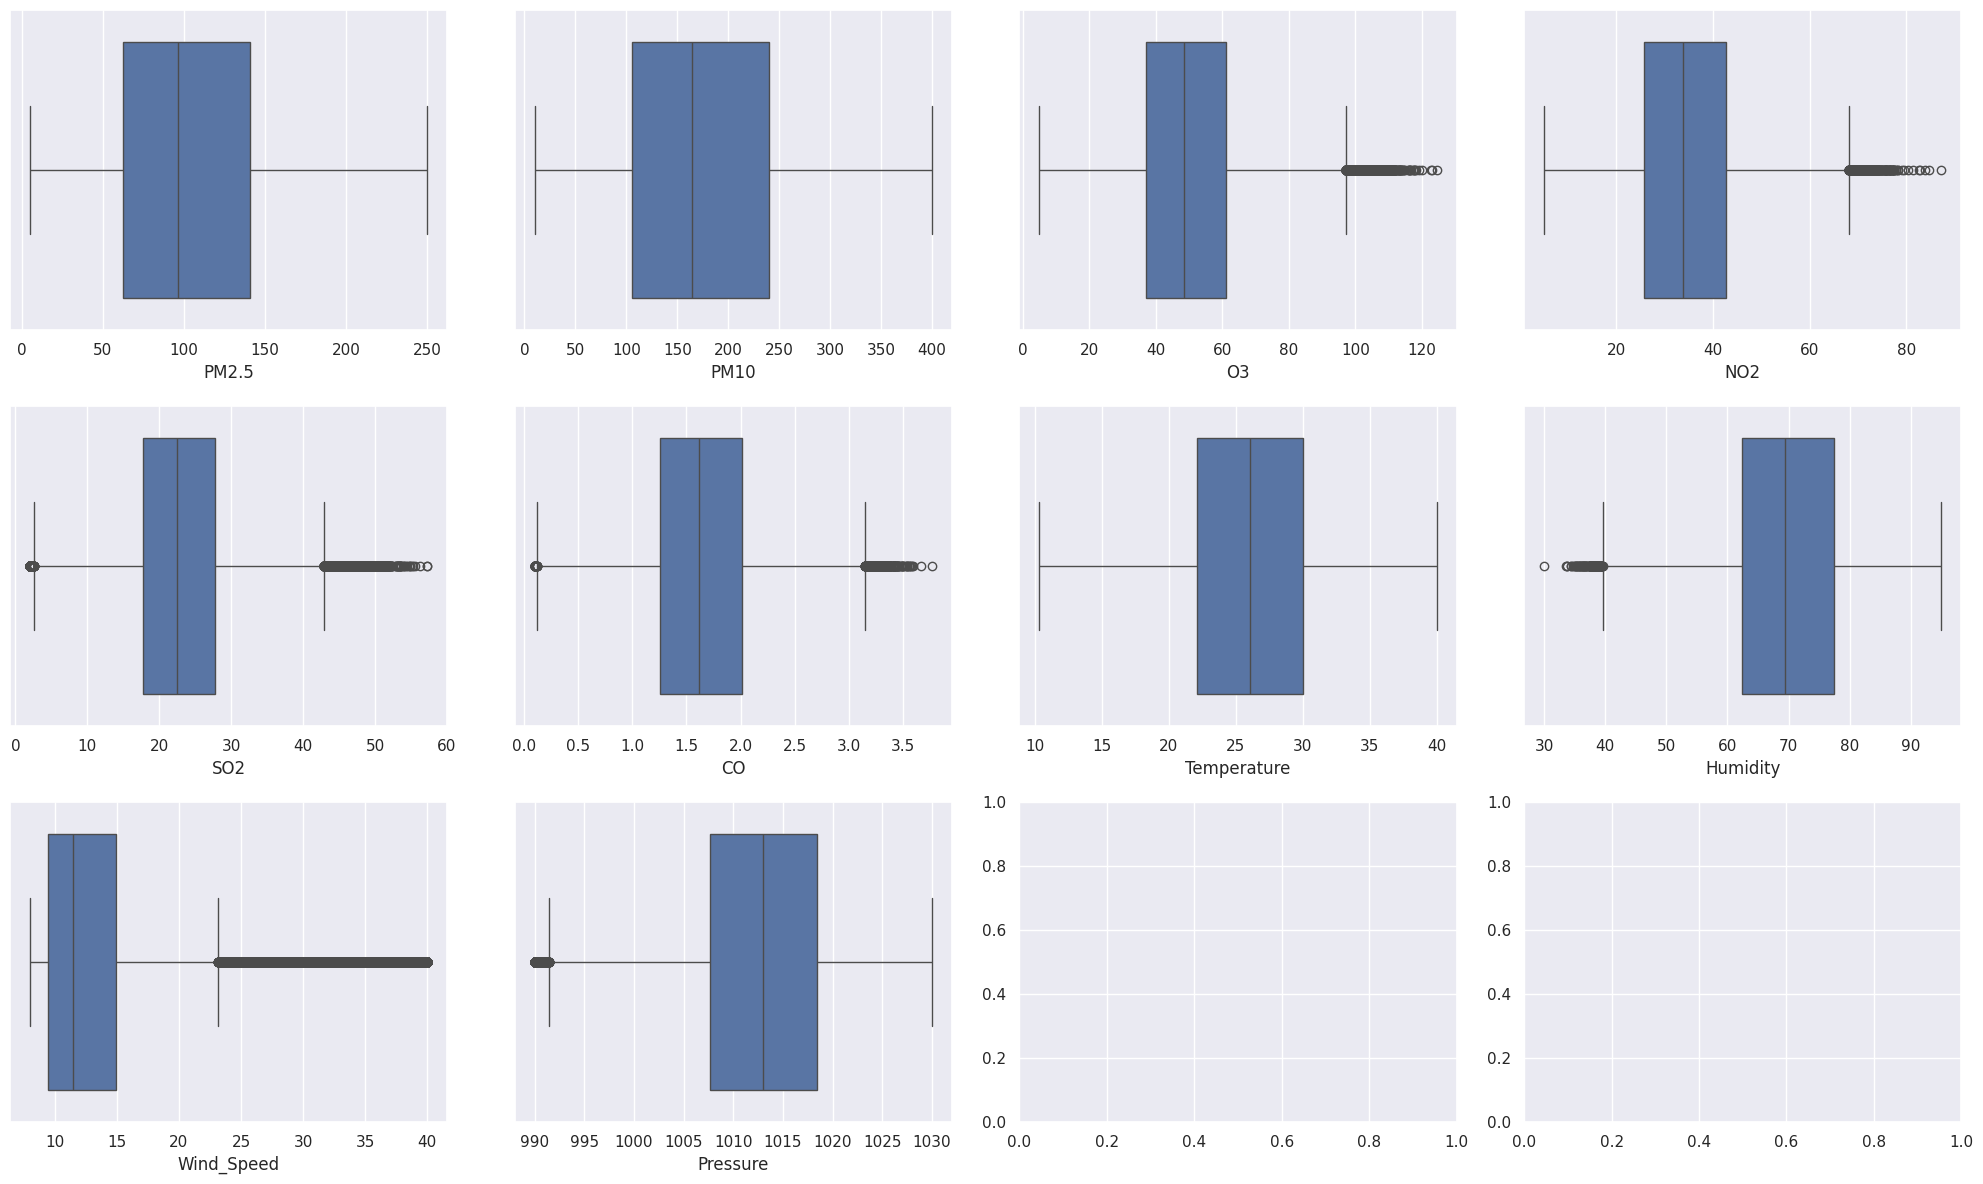

In [29]:
# Boxplots for numerical features
num_cols = ['PM2.5','PM10','O3','NO2','SO2','CO','Temperature','Humidity','Wind_Speed','Pressure']

fig,axs = plt.subplots(nrows=3, ncols=4, figsize=(20,12))
axs = axs.flatten()

for i, var in enumerate(num_cols):
    sns.boxplot(x=var, data=df, ax=axs[i])

fig.tight_layout()
plt.show()